# Loading BatMo BDF CSV data

This notebook shows how to load a BatMo BDF CSV file with the built-in `batmo_bdf` loader, inspect the resulting cellpy data object, extract useful pandas DataFrames, make a simple voltage-capacity plot, and export the processed data to other formats.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

# Changes to the cellpy repo can directly be used without installing the package. This is useful for development and testing.
repo_root = next(
    (path for path in [Path.cwd(), Path.cwd().parent] if (path / "cellpy" / "__init__.py").exists()),
    None,
)
if repo_root is not None and str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import cellpy

%matplotlib inline

## Locate the example file

The notebook first looks for `batmo_bdf.csv` in `examples/data`. In a source checkout, the same test file is also available in `testdata/data`.

In [2]:
candidates = [
    Path("data/batmo_bdf.csv"),
    Path("examples/data/batmo_bdf.csv"),
    Path("../testdata/data/batmo_bdf.csv"),
    Path("testdata/data/batmo_bdf.csv"),
]

raw_file = next((path for path in candidates if path.exists()), None)
if raw_file is None:
    raise FileNotFoundError("Could not find batmo_bdf.csv in examples/data or testdata/data")

raw_file

PosixPath('../testdata/data/batmo_bdf.csv')

## Load with the BatMo loader

BatMo BDF CSV files are loaded by passing `instrument="batmo_bdf"`. The example data starts with a discharge step, so `cycle_mode="anode"` is used here.

In [3]:
c = cellpy.get(
    raw_file,
    instrument="batmo_bdf",
    cycle_mode="anode",
    mass=1.0,
)

c

(cellpy) - parsing with pandas.read_csv: /tmp/batmo_bdf.csv
(cellpy) - parameters: self.sep=',', self.skiprows=0, self.header=0, self.encoding='utf-8', self.decimal='.'
(cellpy) - running post-processor: rename_headers
(cellpy) - running post-processor: cumulate_capacity_within_cycle
(cellpy) - running post-processor: set_index


,data_point,test_time,date_time,end_voltage_charge,end_voltage_discharge,charge_capacity,discharge_capacity,coulombic_efficiency,cumulated_coulombic_efficiency,cumulated_charge_capacity,...,cumulated_charge_capacity_absolute,cumulated_discharge_capacity_absolute,coulombic_difference_absolute,cumulated_coulombic_difference_absolute,discharge_capacity_loss_absolute,charge_capacity_loss_absolute,cumulated_discharge_capacity_loss_absolute,cumulated_charge_capacity_loss_absolute,shifted_charge_capacity_absolute,shifted_discharge_capacity_absolute
count,109.000000,1.090000e+02,109,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,...,109.000000,109.000000,109.000000,109.000000,108.000000,108.000000,108.000000,108.000000,109.000000,109.000000
mean,10885.697248,8.374226e+05,1970-01-10 16:37:02.568807339,3.590381,2.512286,0.132781,0.133794,99.660461,5467.332177,7.326264,...,7326.264370,7430.245198,1.013051,103.980828,1.178949,0.088772,144.216483,26.409553,103.980828,237.774513
min,553.000000,2.624200e+05,1970-01-04 00:53:40,3.581278,2.363354,0.131195,0.131195,57.446809,57.446809,0.158948,...,158.947898,276.687081,-8.325842,103.358183,-16.147088,-10.091930,127.326517,3.784474,103.358183,234.553273
25%,6053.000000,5.717800e+05,1970-01-07 14:49:40.000000001,3.590478,2.507750,0.131195,0.131195,100.000000,2767.780143,3.784726,...,3784.726054,3888.084237,0.000000,103.358183,0.000000,0.000000,145.491991,27.752808,103.358183,234.553273
50%,10886.000000,8.374600e+05,1970-01-10 16:37:40.000000001,3.590478,2.507750,0.131195,0.131195,100.000000,5467.780143,7.326993,...,7326.993489,7430.351672,0.000000,103.358183,0.000000,0.000000,145.491991,27.752808,103.358183,234.553273
75%,15719.000000,1.103140e+06,1970-01-13 18:25:40.000000001,3.590478,2.507750,0.131195,0.131195,100.000000,8167.780143,10.869261,...,10869.260925,10972.619108,0.000000,103.358183,0.000000,0.000000,145.491991,27.752808,103.358183,234.553273
max,21206.000000,1.411480e+06,1970-01-17 08:04:40.000000001,3.596597,2.619610,0.158948,0.276687,105.670103,10862.990274,14.473089,...,14473.089133,14583.511667,117.739184,117.739184,129.849500,10.091930,145.491991,27.752808,117.739184,394.426265
std,5709.996761,3.144652e+05,NaN,0.001768,0.026906,0.005277,0.014522,4.168069,3161.151011,4.152657,...,4152.656567,4152.436458,11.347850,2.201780,12.704656,1.895045,4.502405,4.653151,2.201780,16.377038
,data_point,test_time,date_time,end_voltage_charge,end_voltage_discharge,charge_capacity,discharge_capacity,coulombic_efficiency,cumulated_coulombic_efficiency,cumulated_charge_capacity,...,cumulated_charge_capacity_absolute,cumulated_discharge_capacity_absolute,coulombic_difference_absolute,cumulated_coulombic_difference_absolute,discharge_capacity_loss_absolute,charge_capacity_loss_absolute,cumulated_discharge_capacity_loss_absolute,cumulated_charge_capacity_loss_absolute,shifted_charge_capacity_absolute,shifted_discharge_capacity_absolute
cycle_index,,,,,,,,,,,,,,,,,,,,,


## Inspect the processed data

After loading, `cellpy` has generated the raw data table, the step table, and the summary table.

In [4]:
raw = c.data.raw
steps = c.data.steps
summary = c.data.summary

print(f"Raw points: {len(raw):,}")
print(f"Cycles: {len(c.get_cycle_numbers())}")
print(f"Step types: {steps['type'].value_counts().to_dict()}")

Raw points: 21,206
Cycles: 109
Step types: {'rest': 117, 'discharge': 110, 'charge': 109, 'ocvrlx_up': 109}


In [5]:
raw[[
    "data_point",
    "test_time",
    "step_time",
    "current",
    "voltage",
    "step_index",
    "cycle_index",
    "charge_capacity",
    "discharge_capacity",
]].head()

,data_point,test_time,step_time,current,voltage,step_index,cycle_index,charge_capacity,discharge_capacity
data_point,,,,,,,,,
1,1,500.0,0.0,-0.006055,3.311215,1,1,0.0,0.000000
2,2,1000.0,500.0,-0.006055,3.310550,1,1,0.0,0.000841
3,3,1500.0,1000.0,-0.006055,3.309933,1,1,0.0,0.001682
4,4,2000.0,1500.0,-0.006055,3.309573,1,1,0.0,0.002523
5,5,2500.0,2000.0,-0.006055,3.309229,1,1,0.0,0.003364


In [6]:
steps[["cycle", "step", "type", "point_min", "point_max", "voltage_first", "voltage_last"]].head(10)

,cycle,step,type,point_min,point_max,voltage_first,voltage_last
0,1,1,discharge,1,140,3.311215,2.596938
1,1,2,rest,141,156,2.754796,2.780684
2,1,3,charge,157,346,2.818439,3.595000
3,1,4,rest,347,362,3.581786,3.581428
4,1,5,discharge,363,553,3.565638,2.363354
5,2,6,ocvrlx_up,554,568,2.471637,2.561520
6,2,7,charge,569,725,2.984307,3.581278
7,2,8,rest,726,741,3.470661,3.450568
8,2,9,discharge,742,888,3.336315,2.619608
9,2,10,ocvrlx_up,889,905,2.896960,3.041850


In [7]:
summary.head()

,data_point,test_time,date_time,end_voltage_charge,end_voltage_discharge,charge_capacity,discharge_capacity,coulombic_efficiency,cumulated_coulombic_efficiency,cumulated_charge_capacity,...,cumulated_charge_capacity_absolute,cumulated_discharge_capacity_absolute,coulombic_difference_absolute,cumulated_coulombic_difference_absolute,discharge_capacity_loss_absolute,charge_capacity_loss_absolute,cumulated_discharge_capacity_loss_absolute,cumulated_charge_capacity_loss_absolute,shifted_charge_capacity_absolute,shifted_discharge_capacity_absolute
cycle_index,,,,,,,,,,,,,,,,,,,,,
1,553,262420.0,1970-01-04 00:53:40,3.595000,2.363354,0.158948,0.276687,57.446809,57.446809,0.158948,...,158.947898,276.687081,117.739184,117.739184,NaN,NaN,NaN,NaN,117.739184,394.426265
2,905,283300.0,1970-01-04 06:41:40,3.581278,2.619608,0.155163,0.146838,105.670103,163.116912,0.314111,...,314.111322,423.524663,-8.325842,109.413341,129.849500,3.784474,129.849500,3.784474,109.413341,256.250923
3,1248,303820.0,1970-01-04 12:23:40,3.582400,2.588512,0.147342,0.147847,99.658703,262.775615,0.461453,...,461.453500,571.371438,0.504597,109.917938,-1.009193,7.821246,128.840307,11.605720,109.917938,257.764712
4,1593,324460.0,1970-01-04 18:07:40,3.587022,2.534302,0.148351,0.148856,99.661017,362.436632,0.609805,...,609.804871,720.227405,0.504597,110.422534,-1.009193,-1.009193,127.831114,10.596527,110.422534,259.278502
5,1939,345220.0,1970-01-04 23:53:40,3.593878,2.607985,0.149361,0.149361,100.000000,462.436632,0.759165,...,759.165435,869.587970,0.000000,110.422534,-0.504597,-1.009193,127.326517,9.587334,110.422534,259.783098


## Make a quick raw-data plot

The raw table is a normal pandas DataFrame, so you can use pandas, matplotlib, seaborn, plotly, or the cellpy plotting helpers.

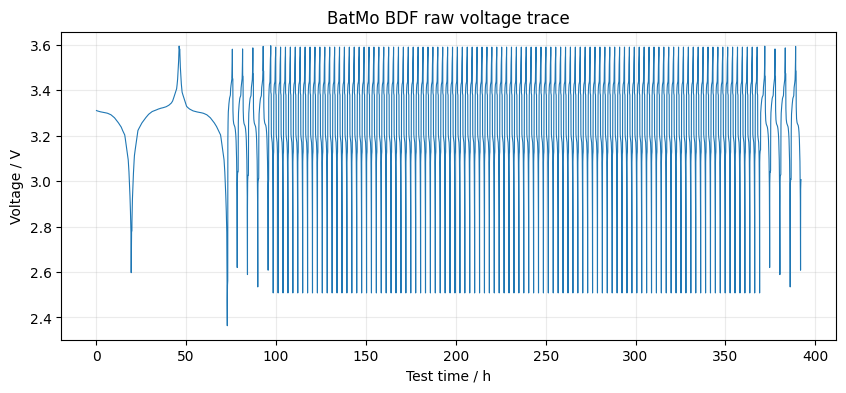

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(raw["test_time"] / 3600, raw["voltage"], lw=0.8)
ax.set_xlabel("Test time / h")
ax.set_ylabel("Voltage / V")
ax.set_title("BatMo BDF raw voltage trace")
ax.grid(alpha=0.25);

## Extract voltage-capacity curves

`get_cap()` returns tidy pandas DataFrames that are convenient for plotting or further analysis. Here `mode="absolute"` keeps the capacities in absolute units.

In [17]:
cycles = [6, 10]
curve = c.get_cap(
    cycles=cycles,
    method="forth-and-forth",
    categorical_column=True,
    label_cycle_number=True,
    mode="absolute",
)

curve.head()

,cycle,voltage,capacity,direction
2735,10,3.226422,0.000000,-1
2736,10,3.213438,2.018386,-1
2737,10,3.209859,4.036772,-1
2738,10,3.206538,6.055158,-1
2739,10,3.203454,8.073544,-1


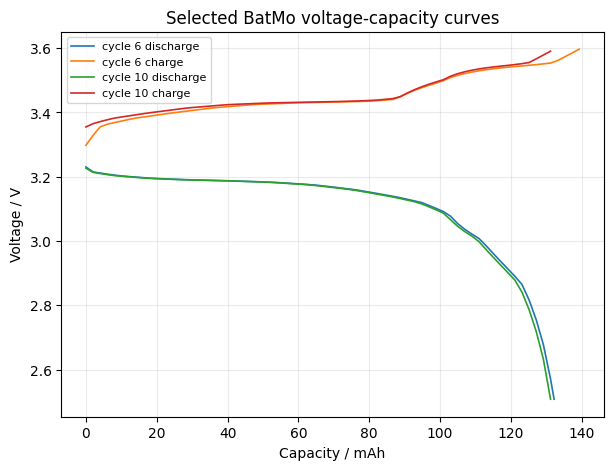

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))

for (cycle, direction), frame in curve.groupby(["cycle", "direction"]):
    label = f"cycle {cycle} {'charge' if direction > 0 else 'discharge'}"
    ax.plot(frame["capacity"], frame["voltage"], label=label, lw=1.2)

ax.set_xlabel("Capacity / mAh")
ax.set_ylabel("Voltage / V")
ax.set_title("Selected BatMo voltage-capacity curves")
ax.legend(fontsize=8)
ax.grid(alpha=0.25);

## Export to other formats

The processed cellpy object can be saved as a cellpy HDF5 file and exported to CSV or Excel. The CSV export below keeps the output compact by exporting summary and cycle data only.

In [11]:
out_dir = Path("out/batmo_bdf")
csv_dir = out_dir / "csv"
csv_dir.mkdir(parents=True, exist_ok=True)

cellpy_file = out_dir / "batmo_bdf.cellpy"
excel_file = out_dir / "batmo_bdf.xlsx"

c.save(cellpy_file)
c.to_csv(datadir=csv_dir, raw=False, summary=True, cycles=True, last_cycle=5)
c.to_excel(excel_file, cycles=[1, 2, 10], raw=False)

sorted(path.name for path in out_dir.iterdir())

<ApiModule 'cellpy.readers.externals'>


['batmo_bdf.cellpy', 'batmo_bdf.xlsx', 'csv']

## Reload the saved cellpy file

Once saved as a cellpy file, loading is faster and does not require specifying the BatMo raw-data loader again.

In [12]:
c2 = cellpy.get(cellpy_file)

print(f"Reloaded raw points: {len(c2.data.raw):,}")
print(f"Reloaded cycles: {len(c2.get_cycle_numbers())}")

Reloaded raw points: 21,206
Reloaded cycles: 109
